# 15 — Managing layers

Every drawing call on a `Map` registers a **layer**: a named, inspectable description of what was drawn and how.
Once a figure exists you can list its layers, read one back, hide it, reorder it, swap its description, remove
it, or hand the whole figure over as plain data and rebuild it later.

This is what separates a `Map` from a pile of matplotlib calls. A script that draws once and saves does not need
it; anything that *edits* a figure — a dashboard, a layer switcher, a report regenerated with one layer swapped —
depends on it entirely.

API: [`Scene`](../reference/static_scene.md), [`Map`](../reference/static_map.md).

> **Where this data comes from.** Everything in this notebook is real, downloaded with
> [earthlens](https://github.com/serapeum-org/earthlens) and committed under `examples/data/`:
> WorldPop population grids, OpenStreetMap roads, GBIF bird occurrences and geoBoundaries admin
> polygons. `examples/data/ATTRIBUTION.md` records each source and its licence.


**Setup**.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.dataset import Dataset
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits two levels up: docs/examples -> repo root.
DATA = Path("../../examples/data")

# UTM zone 32N: a metric CRS, correct for south-west Germany.
UTM32 = 25832


## The data

The **WorldPop** 1 km population grid for Germany, the 16 **geoBoundaries** states, and 3,000 **GBIF** bird
records around Heidelberg — a raster, polygons and points, which is enough to show ordering and visibility
properly.

In [2]:
pop = Dataset.read_file(str(DATA / "germany_pop_2020_1km.tif"))
states = FeatureCollection.read_file(str(DATA / "germany_adm1.geojson"))
birds = FeatureCollection.read_file(str(DATA / "heidelberg_birds_2023.geojson"))
print(f"raster {pop.rows}x{pop.columns} EPSG:{pop.epsg} | {len(states)} states | {len(birds)} bird records")

raster 934x1100 EPSG:4326 | 16 states | 3000 bird records


## Layers have names, and you should choose them

Every call takes `name=`. Without it an id is generated from the kind (`raster-1`, `polygons-1`, …) — fine for a
throwaway figure, a liability for anything you intend to edit, because you cannot address a layer whose name you
did not choose.

layer ids: ['population', 'states']


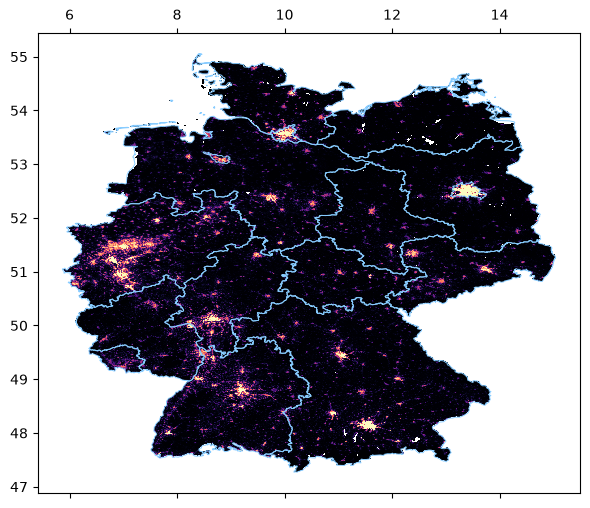

In [3]:
m = Map(crs=pop.epsg, figsize=(7, 8))
m.field(pop, name="population", cmap="magma", vmin=0, vmax=2000)
m.polygons(states, name="states", edgecolor="#88ccff", linewidth=0.7)
print("layer ids:", m.layer_ids)
m.fig;

`layer_ids` is the figure's table of contents, in draw order. Those two strings are the handles every method
below takes.

## Reading a layer back

Two different questions, two accessors:

| accessor | returns | use it to |
|---|---|---|
| `get_layer(id)` | a `LayerSpec` — the **description** | ask what was drawn, and how |
| `artist(id)` | the matplotlib **artist** | reach the drawn object itself |

Prefer `artist(id)` over digging into private renderer state; it is the supported way in.

In [4]:
spec = m.get_layer("population")
print("kind:      ", spec.kind)
print("label:     ", spec.label)
print("visible:   ", spec.visible)
print("symbology: ", spec.symbology)
print("artist:    ", type(m.artist("population")).__name__)

kind:       raster
label:      population
visible:    True
symbology:  Symbology(encodings={'color': Encoding(channel='color', value=None, field='Band_1', scale=Scale(vmin=0.0, vmax=2000.0, scheme=None, breaks=(), categories=(), missing=None, over=None, under=None), output_range=None, guide=None)}, props={'via': 'imshow', 'band': 1, 'cmap': 'magma', 'levels': None, 'interval': None, 'add_colorbar': False, 'default_cmap': 'viridis', 'zorder': None, 'opts': {'vmin': 0, 'vmax': 2000}})
artist:     AxesImage


The `LayerSpec` is a frozen description — data, not a live handle. That is what makes it safe to store, compare
and serialise, and it is the basis of the round trip at the end of this notebook.

## Showing and hiding — `set_visible`

`set_visible(id, False)` hides a layer **and records it as hidden**, so anything reading the figure's description
agrees with what is on screen. That consistency is the point: a layer switcher built on `figure_spec` would
otherwise drift out of step with the axes.

In [5]:
m.set_visible("states", False)
print("states visible:", m.get_layer("states").visible)
m.fig;

states visible: False


The state boundaries are gone and the description says so. Putting them back is the same call with `True`.

In [6]:
m.set_visible("states", True)
print("states visible:", m.get_layer("states").visible)

states visible: True


## Draw order — `move_layer`

Layers paint in list order, so the last drawn sits on top. `move_layer(id, index)` moves one. Build a figure
where the order visibly matters: all the bird records, and one common species on top of them.

166 Parus major records of 3000
before: ['all-records', 'parus-major']


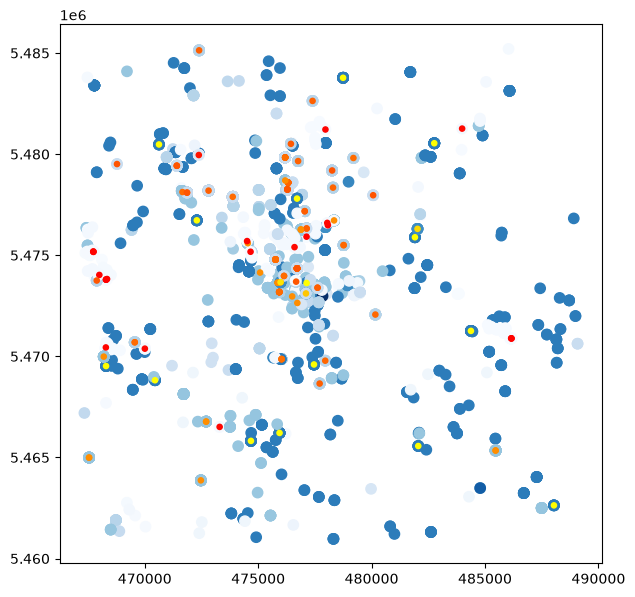

In [7]:
tits = FeatureCollection(birds[birds["species"] == "Parus major"])
print(f"{len(tits)} Parus major records of {len(birds)}")
pts = Map(crs=UTM32, figsize=(7, 7))
pts.points(birds, name="all-records", size=55, cmap="Blues")
pts.points(tits, name="parus-major", size=14, cmap="autumn")
print("before:", pts.layer_ids)
pts.fig;

In [8]:
pts.move_layer("parus-major", 0)
print("after: ", pts.layer_ids)
pts.fig;

after:  ['parus-major', 'all-records']


Moved to position 0, the *Parus major* layer paints first, so the larger blue markers now cover it. Reordering
fixes a layer drawn in the wrong sequence without rebuilding the figure.

## Swapping a description — `replace_layer`

`replace_layer` takes a whole `LayerSpec` and swaps it in, **keeping the layer's id and its place in draw
order**. The spec is a frozen dataclass, so the idiomatic way to build the new one is `dataclasses.replace`.

In [9]:
import dataclasses

relabelled = dataclasses.replace(m.get_layer("population"), label="People per km²")
m.replace_layer(relabelled)
print("label is now:", m.get_layer("population").label)
print("ids unchanged:", m.layer_ids)

label is now: People per km²
ids unchanged: ['population', 'states']


Same id, same position, new description. This is the mechanism behind "change the ramp and redraw" without
disturbing anything else on the figure.

## Removing — `remove_layer`

`remove_layer(id)` takes the layer off the figure entirely: gone from `layer_ids`, gone from the axes.

In [10]:
m.remove_layer("states")
print("ids after removal:", m.layer_ids)
m.fig;

ids after removal: ['population']


## Registering your own artist — `add_layer`

Sometimes you need a matplotlib call the layer API does not wrap. Draw it yourself on `map.ax`, then **register
it as a layer** so it gains an id and takes part in visibility and ordering like any other.

ids: ['polygons-1', 'survey-route']


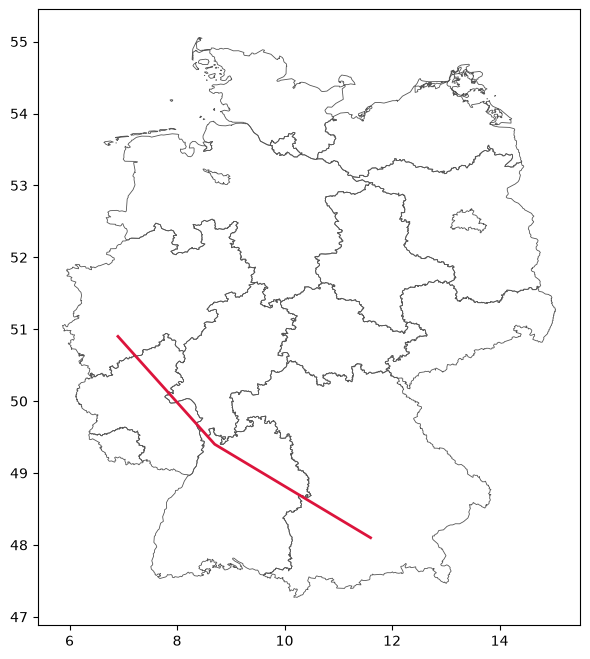

In [11]:
own = Map(crs=4326, figsize=(7, 8))
own.polygons(states, edgecolor="#555555", linewidth=0.6)
(line,) = own.ax.plot([6.9, 8.7, 11.6], [50.9, 49.4, 48.1], color="crimson", linewidth=2)
own.add_layer(line, name="survey-route")
print("ids:", own.layer_ids)
own.fig;

The hand-drawn route is now a first-class layer — `set_visible("survey-route", False)` works on it. Use this as
the escape hatch, not the habit: a registered artist carries no source description, so it cannot be redrawn from
`figure_spec` the way a `field` or `points` layer can.

## The figure as data — `figure_spec` and `from_figure`

`figure_spec` hands back the **whole scene as a value**: its layers, their sources and the view.
`Map.from_figure` takes one and builds the figure again. That round trip is how a figure travels between
processes, gets stored, or is diffed between runs.

In [12]:
spec = m.figure_spec
print("layers:", [layer.id for layer in spec.layers])
print("viewport:", m.viewport)

layers: ['population']
viewport: Viewport(crs=4326, bounds=None, domain=None, globe=False, center=None, zoom=None)


rebuilt ids: ['population']


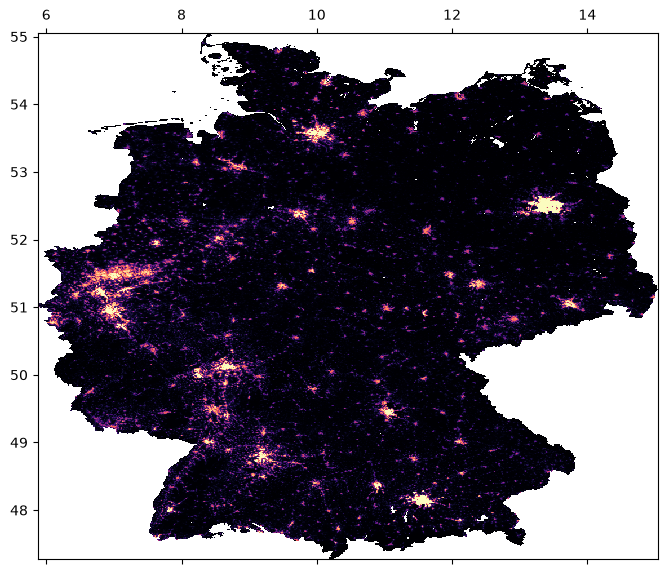

In [13]:
rebuilt = Map.from_figure(spec)
print("rebuilt ids:", rebuilt.layer_ids)
rebuilt.fig;

The rebuilt figure carries the same layers as the original. Note what had to be true: each layer's source must be
something the description can name. That is why a path-backed layer round-trips and an `add_layer` artist does
not.

## Reacting to a click — `on_pick`

`on_pick(callback)` registers a function called when the reader clicks a layer. The callback receives a `Pick`:

| field | meaning |
|---|---|
| `layer_id` | which layer was hit |
| `x`, `y` | where the click landed, in display-CRS coordinates |
| `hits` | the indices within the layer that were hit |
| `event` | the underlying matplotlib pick event |

Picking needs a **live GUI backend** to fire, so it does nothing in a saved notebook — the cell below registers
the handler and shows what it would receive. Run it under `%matplotlib widget` to click for real.

handler registered; clicks are delivered under an interactive backend


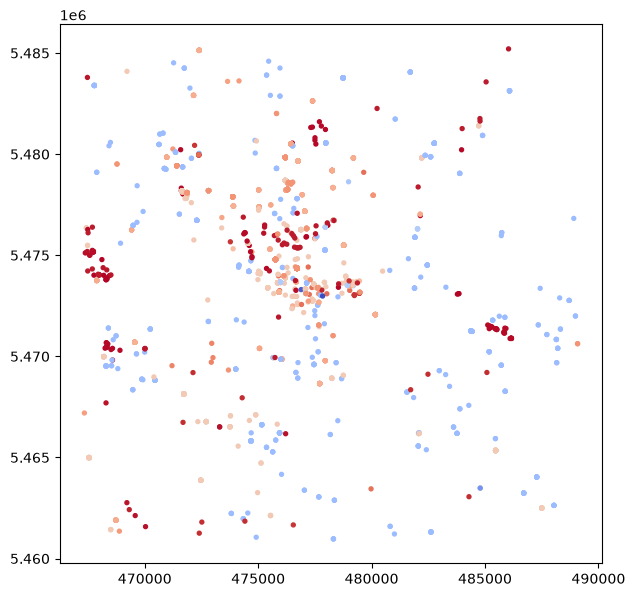

In [14]:
clicked = []

def report(pick):
    clicked.append(pick)
    print(f"clicked layer {pick.layer_id!r} at ({pick.x:.0f}, {pick.y:.0f}), hits={pick.hits}")

picker = Map(crs=UTM32, figsize=(7, 7))
picker.points(birds, name="bird-records", size=8)
picker.on_pick(report)
print("handler registered; clicks are delivered under an interactive backend")
picker.fig;

## Takeaway

- Pass `name=` to every layer you might want to address later; generated ids are for throwaway figures.
- `get_layer(id)` gives the **description**, `artist(id)` the **matplotlib object**.
- `set_visible`, `move_layer`, `replace_layer`, `remove_layer` all edit a live figure by id.
- `add_layer` registers an artist you drew yourself — the escape hatch for anything the API does not wrap.
- `figure_spec` / `Map.from_figure` turn a scene into data and back, which is what makes figures storable.
- `on_pick` delivers clicks as a `Pick`, under an interactive backend.

Next: [`16_framing_and_insets`](16_framing_and_insets.ipynb).